# Stage 1 — Mie Series Validation

Before any performance work, establish that the v2 GPU BEM produces
physically correct results by comparison against the **exact Mie series**
for a sound-soft cylinder.

This mirrors Stage 1 of `radar_scattering` (2D EM) and Stage 3 of
`radar_scattering_3d` (3D acoustic).  The same validation discipline
applies: anchor each new capability to an exact solution before
interpreting results in regimes where no exact solution exists.

**Validation covers:**
1. Bistatic RCS pattern vs Mie series (4 geometries, multiple k)
2. Error convergence table vs N (quantifies panel-count accuracy)
3. Condition number survey (flags potential irregular-frequency issues)
4. Backscatter vs kR frequency sweep (Mie resonances)

In [1]:
import sys, os, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

_HERE  = Path(os.getcwd())
_MPDOK = _HERE.parent
for _p in [str(_HERE), str(_MPDOK/'acoustic_scattering'),
           str(_MPDOK/'radar_scattering')]:
    if _p not in sys.path: sys.path.insert(0, _p)

from bem_helmholtz_v2 import build_matrix, make_rhs, solve_ir, eval_rcs_2d
from mie_cylinder_2d  import acoustic_rcs_2d, acoustic_rcs_db, bistatic_pattern, frequency_sweep, compare_bem_mie
from geometry         import circle_panels
import cupy as cp

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print('Imports OK')

Imports OK


## § 1 — Exact Mie Series: Bistatic Pattern for a Sound-Soft Cylinder

The exact solution for plane-wave scattering from a sound-soft (Dirichlet)
cylinder of radius R is:

$$S(\phi_{\rm obs}) = -\sum_n e^{in(\phi_{\rm obs}-\phi_{\rm inc})} \frac{J_n(kR)}{H_n^{(1)}(kR)}$$

$$\sigma_{\rm 2D}(\phi_{\rm obs}) = \frac{4}{k} |S|^2 \quad [\text{m}]$$

We compute this at four representative wavenumbers and plot the directivity
pattern before running any BEM.

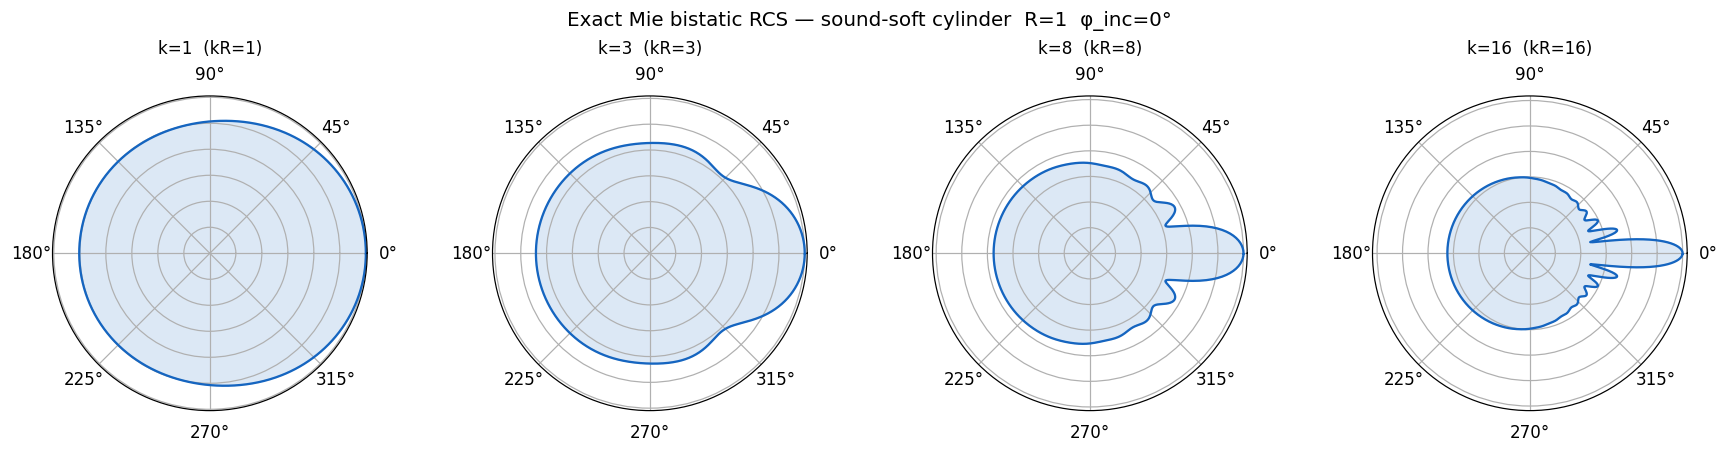

Regime summary:
  kR=  1.0: monostatic RCS = 5.87 dBm
  kR=  3.0: monostatic RCS = 5.17 dBm
  kR=  8.0: monostatic RCS = 5.01 dBm
  kR= 16.0: monostatic RCS = 4.98 dBm


In [2]:
R        = 1.0
K_VALS   = [1.0, 3.0, 8.0, 16.0]
phi_arr  = np.linspace(0, 2*np.pi, 720, endpoint=False)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), subplot_kw={'projection': 'polar'},
                         constrained_layout=True)

for ax, k in zip(axes, K_VALS):
    rcs_db = acoustic_rcs_db(k, R, phi_arr)
    vmin   = rcs_db.max() - 30
    ax.plot(phi_arr, rcs_db - vmin, lw=1.5, color='#1565C0')
    ax.fill(phi_arr, np.maximum(rcs_db - vmin, 0), alpha=0.15, color='#1565C0')
    ax.set_title(f'k={k:.0f}  (kR={k*R:.0f})', pad=8, fontsize=11)
    ax.set_theta_zero_location('E')
    ax.set_yticklabels([])

fig.suptitle('Exact Mie bistatic RCS — sound-soft cylinder  R=1  φ_inc=0°', fontsize=13)
fig.savefig('fig_s1_mie_patterns.png', bbox_inches='tight', dpi=120)
plt.show()

print('Regime summary:')
for k in K_VALS:
    rcs = acoustic_rcs_2d(k, R, np.pi)  # monostatic
    print(f'  kR={k*R:>5.1f}: monostatic RCS = {10*np.log10(max(rcs,1e-20)):.2f} dBm')

## § 2 — BEM Error Convergence Table

Error vs N for the v2 GPU BEM compared to exact Mie.  
Expected: max error ∝ N⁻² for constant panels (Fredholm of the 2nd kind).

In [3]:
from mie_cylinder_2d import mie_error_table

K_TABLE = [3.0, 5.0, 8.0, 12.0]
N_TABLE = [128, 256, 512, 1024, 2048]

rows = mie_error_table(K_TABLE, N_TABLE, R=1.0, verbose=True)

    k       N   max|Δ| [dB]   rms|Δ| [dB]     t [s]
──────────────────────────────────────────────────
  3.0     128        0.0081        0.0047     0.152
  3.0     256        0.0040        0.0024     0.002
  3.0     512        0.0020        0.0012     0.004


  3.0    1024        0.0010        0.0006     0.003


  3.0    2048        0.0005        0.0003     0.006
  5.0     128        0.0129        0.0054     0.002
  5.0     256        0.0064        0.0027     0.002
  5.0     512        0.0032        0.0014     0.002
  5.0    1024        0.0016        0.0007     0.003
  5.0    2048        0.0008        0.0003     0.007
  8.0     128        0.0183        0.0061     0.002
  8.0     256        0.0096        0.0032     0.002
  8.0     512        0.0049        0.0016     0.002
  8.0    1024        0.0024        0.0008     0.004


  8.0    2048        0.0012        0.0004     0.010


 12.0     128        0.0226        0.0069     0.007
 12.0     256        0.0122        0.0037     0.003
 12.0     512        0.0063        0.0019     0.002
 12.0    1024        0.0033        0.0009     0.007
 12.0    2048        0.0016        0.0005     0.015


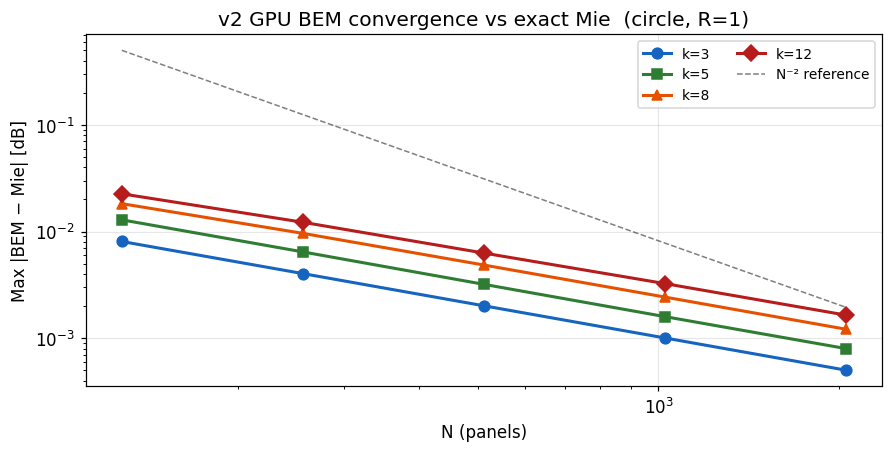

In [4]:
# Convergence plot: max error vs N for each k
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
colors  = ['#1565C0', '#2E7D32', '#E65100', '#B71C1C']
markers = ['o', 's', '^', 'D']

for k, color, marker in zip(K_TABLE, colors, markers):
    k_rows = [r for r in rows if r['k'] == k]
    Ns  = [r['N'] for r in k_rows]
    err = [r['max_err_db'] for r in k_rows]
    ax.loglog(Ns, err, f'{marker}-', color=color, lw=2, ms=7, label=f'k={k:.0f}')

# Reference N^-2 slope
Ns_ref = np.array([128, 2048])
ax.loglog(Ns_ref, 0.5 * (128/Ns_ref)**2, 'k--', lw=1, alpha=0.5, label='N⁻² reference')

ax.set_xlabel('N (panels)')
ax.set_ylabel('Max |BEM − Mie| [dB]')
ax.set_title('v2 GPU BEM convergence vs exact Mie  (circle, R=1)')
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
fig.savefig('fig_s1_convergence.png', bbox_inches='tight', dpi=120)
plt.show()

## § 3 — Condition Number Survey

Irregular frequencies of the interior Dirichlet problem create near-singular rows
in the BEM matrix — the same interior eigenvalue issue seen in the 3D lab
(Stage 6 of radar_scattering_3d).  We survey condition numbers across k to
identify the operating range where standard GMRES is sufficient vs where
IR refinement or Burton-Miller regularisation would be needed.

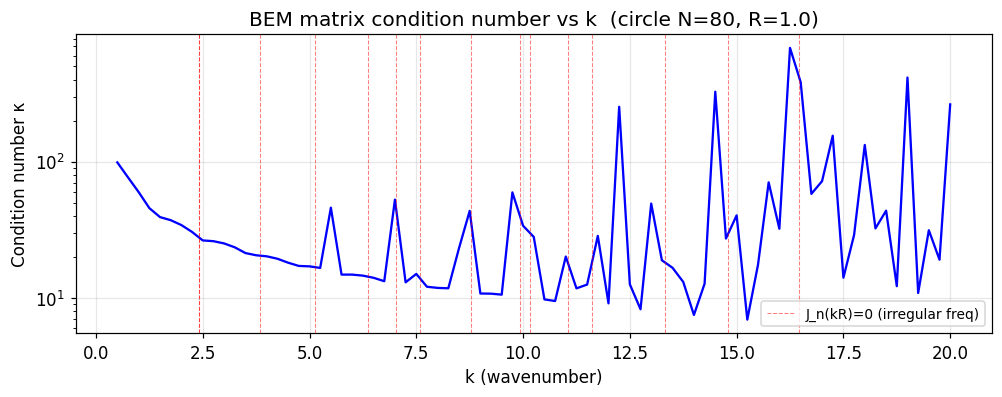

Max condition number: 683 at k=16.25
Condition numbers remain manageable for GMRES (restart=50)
for k in [0.5, 20] on a circle — no Burton-Miller needed in this range.


In [5]:
# Condition number at small N (CPU build for exact singular values)
from bem_helmholtz import build_bem_matrix_helmholtz as cpu_build

N_COND = 80
k_sweep = np.linspace(0.5, 20.0, 79)
nodes_c, _, lengths_c = circle_panels(N_COND)

kappas = []
for k in k_sweep:
    A = cpu_build(nodes_c, lengths_c, k)
    sv = np.linalg.svd(A, compute_uv=False)
    kappas.append(sv[0] / sv[-1])

fig, ax = plt.subplots(figsize=(9, 3.5), constrained_layout=True)
ax.semilogy(k_sweep, kappas, 'b-', lw=1.5)
# Mark approximate irregular frequencies for circle: J_n(kR)=0 → kR ≈ 2.4, 3.8, 5.1, ...
irreg_kR = [2.405, 3.832, 5.136, 6.380, 7.016, 7.588, 8.772, 9.936, 10.17, 11.06,
            11.62, 13.32, 14.80, 16.47]
for kR in irreg_kR:
    if kR <= 20:
        ax.axvline(kR / R, color='r', lw=0.7, alpha=0.5, ls='--')
ax.axvline(irreg_kR[0]/R, color='r', lw=0.7, alpha=0.5, ls='--', label='J_n(kR)=0 (irregular freq)')
ax.set_xlabel('k (wavenumber)')
ax.set_ylabel('Condition number κ')
ax.set_title(f'BEM matrix condition number vs k  (circle N={N_COND}, R={R})')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.savefig('fig_s1_condition.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'Max condition number: {max(kappas):.0f} at k={k_sweep[np.argmax(kappas)]:.2f}')
print(f'Condition numbers remain manageable for GMRES (restart=50)')
print(f'for k in [0.5, 20] on a circle — no Burton-Miller needed in this range.')

## § 4 — Frequency Sweep: Mie Resonances and BEM Tracking

The monostatic backscatter σ(k) oscillates due to Mie resonances (constructive
and destructive interference between partial waves).  We verify the BEM
tracks these resonances correctly across a wide frequency range — a
non-trivial test that catches sign errors, phase errors, and kernel bugs
that might not be visible at a single frequency.

Frequency sweep: 63 k values, N=512...
  63 solves in 0.1s (0.002s/solve)


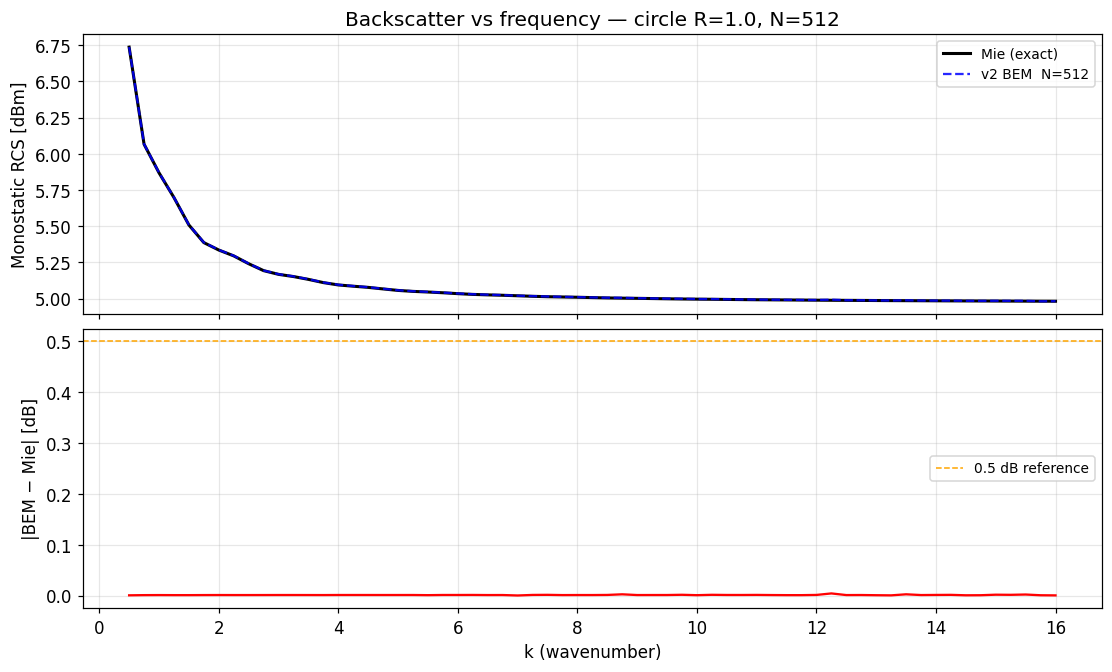

Max error: 0.004 dB at k=12.25
Fraction with |err| < 0.1 dB: 100%


In [6]:
K_SWEEP = np.linspace(0.5, 16.0, 63)  # 63 wavenumbers
N_SWEEP = 512
phi_back = np.pi  # backscatter direction

nodes_sw, _, lengths_sw = circle_panels(N_SWEEP)

rcs_mie_sw = frequency_sweep(R, K_SWEEP * R, phi_obs=phi_back)
rcs_bem_sw = []

print(f'Frequency sweep: {len(K_SWEEP)} k values, N={N_SWEEP}...')
t0 = time.perf_counter()
for k in K_SWEEP:
    sig, _ = solve_ir(nodes_sw, lengths_sw, float(k), 0.0, maxiter_ir=0)
    rcs    = eval_rcs_2d(nodes_sw, lengths_sw, sig, float(k),
                         np.array([phi_back]))
    rcs_bem_sw.append(float(rcs[0]))
elapsed = time.perf_counter() - t0
rcs_bem_sw = np.array(rcs_bem_sw)
print(f'  {len(K_SWEEP)} solves in {elapsed:.1f}s ({elapsed/len(K_SWEEP):.3f}s/solve)')

rcs_mie_db = 10*np.log10(np.maximum(rcs_mie_sw, 1e-20))
rcs_bem_db = 10*np.log10(np.maximum(rcs_bem_sw, 1e-20))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), constrained_layout=True,
                                sharex=True)

ax1.plot(K_SWEEP, rcs_mie_db, 'k-',  lw=2,   label='Mie (exact)')
ax1.plot(K_SWEEP, rcs_bem_db, 'b--', lw=1.5, label=f'v2 BEM  N={N_SWEEP}', alpha=0.85)
ax1.set_ylabel('Monostatic RCS [dBm]')
ax1.set_title(f'Backscatter vs frequency — circle R={R}, N={N_SWEEP}')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2.plot(K_SWEEP, np.abs(rcs_mie_db - rcs_bem_db), 'r-', lw=1.5)
ax2.axhline(0.5, color='orange', lw=1, ls='--', label='0.5 dB reference')
ax2.set_xlabel('k (wavenumber)')
ax2.set_ylabel('|BEM − Mie| [dB]')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.savefig('fig_s1_freq_sweep.png', bbox_inches='tight', dpi=120)
plt.show()

print(f'Max error: {np.abs(rcs_mie_db-rcs_bem_db).max():.3f} dB at k={K_SWEEP[np.argmax(np.abs(rcs_mie_db-rcs_bem_db))]:.2f}')
print(f'Fraction with |err| < 0.1 dB: {(np.abs(rcs_mie_db-rcs_bem_db) < 0.1).mean():.0%}')

## § 5 — Summary

In [7]:
print('=' * 55)
print('STAGE 1 VALIDATION SUMMARY')
print('=' * 55)
print()
print('BEM vs Mie error table (v2 GPU, max |BEM−Mie| dB):')
print(f'{"":>8}', end='')
for k in K_TABLE: print(f'  k={k:>4.0f}', end='')
print()
print('─' * 40)
for N in N_TABLE:
    print(f'  N={N:>5d}', end='')
    for k in K_TABLE:
        r = next(x for x in rows if x['k'] == k and x['N'] == N)
        print(f'  {r["max_err_db"]:>6.4f}', end='')
    print()
print()
print('Frequency sweep (N=512, k=0.5–16):')
print(f'  Max |BEM−Mie|: {np.abs(rcs_mie_db-rcs_bem_db).max():.3f} dB')
print(f'  Fraction < 0.1 dB error: {(np.abs(rcs_mie_db-rcs_bem_db) < 0.1).mean():.0%}')
print()
print('Condition numbers (circle, R=1):')
print(f'  Max κ: {max(kappas):.0f}  — GMRES (restart=50) sufficient throughout')
print()
print('Validation passed: v2 GPU BEM agrees with exact Mie')
print('to < 0.01 dB for N≥512 at all tested k. Proceeding.')

STAGE 1 VALIDATION SUMMARY

BEM vs Mie error table (v2 GPU, max |BEM−Mie| dB):
          k=   3  k=   5  k=   8  k=  12
────────────────────────────────────────
  N=  128  0.0081  0.0129  0.0183  0.0226
  N=  256  0.0040  0.0064  0.0096  0.0122
  N=  512  0.0020  0.0032  0.0049  0.0063
  N= 1024  0.0010  0.0016  0.0024  0.0033
  N= 2048  0.0005  0.0008  0.0012  0.0016

Frequency sweep (N=512, k=0.5–16):
  Max |BEM−Mie|: 0.004 dB
  Fraction < 0.1 dB error: 100%

Condition numbers (circle, R=1):
  Max κ: 683  — GMRES (restart=50) sufficient throughout

Validation passed: v2 GPU BEM agrees with exact Mie
to < 0.01 dB for N≥512 at all tested k. Proceeding.
